## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

## Импорт библиотек

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Загрузка и первичный анализ данных

In [13]:
# Загрузка данных
data = pd.read_csv('german.csv', sep=';')
print(data.head())

# Первичный анализ данных
print(f"Размер датасета: {data.shape}")
print(f"Пропущенные значения: {data.isnull().sum().sum()}")
data.head()

# Описательная статистика
data.describe()

# Разделение на признаки и целевую переменную
X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:  {X_test.shape}")

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

## Анализ распределения классов

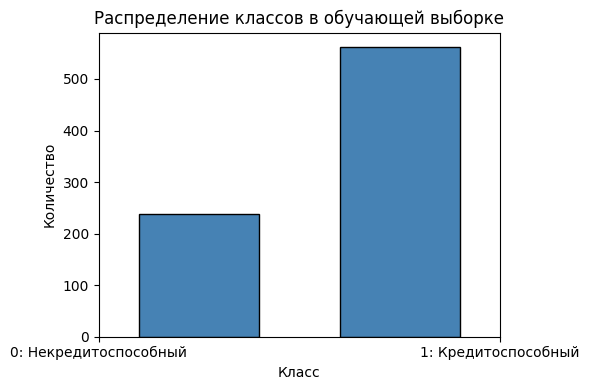

Класс 0: 238 (29.8%)
Класс 1: 562 (70.2%)


In [16]:
plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=2, edgecolor='k', color='steelblue', rwidth=0.6)
plt.xticks([0, 1], ['0: Некредитоспособный', '1: Кредитоспособный'])
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Распределение классов в обучающей выборке')
plt.tight_layout()
plt.show()

unique, counts = np.unique(y_train, return_counts=True)
print(f"Класс 0: {counts[0]} ({counts[0]/len(y_train)*100:.1f}%)")
print(f"Класс 1: {counts[1]} ({counts[1]/len(y_train)*100:.1f}%)")

## Предобработка данных

Для моделей, чувствительных к масштабу (LogisticRegression, KNN), применяем `StandardScaler`. DecisionTree масштабирование не требует.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

print(f"Среднее признаков после scaling (train): {X_train_scaled.mean(axis=0).round(2)}")

Среднее признаков после scaling (train): [-0. -0.  0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0.
  0. -0.]


## Подбор гиперпараметров через GridSearchCV

In [22]:
# Логистическая регрессия
lr_params = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=5,
    scoring='roc_auc',
    verbose=0
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {lr_grid.best_params_}")
print(f"CV ROC-AUC:       {lr_grid.best_score_:.4f}")

Лучшие параметры: {'C': 0.001, 'class_weight': None, 'solver': 'liblinear'}
CV ROC-AUC:       0.7826


In [23]:
# Дерево решений
dt_params = {
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='roc_auc',
    verbose=0
)
dt_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"CV ROC-AUC:       {dt_grid.best_score_:.4f}")

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 20}
CV ROC-AUC:       0.7198


In [24]:
# KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='roc_auc',
    verbose=0
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {knn_grid.best_params_}")
print(f"CV ROC-AUC:       {knn_grid.best_score_:.4f}")

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}
CV ROC-AUC:       0.7670


## Создание финальных моделей с лучшими параметрами

In [26]:
# Финальные модели с найденными гиперпараметрами
logistic_regression_model = lr_grid.best_estimator_
decision_tree_model = dt_grid.best_estimator_
knn_model = knn_grid.best_estimator_

## Оценка моделей

In [27]:
# Вероятности и предсказания
y_prob_logistic      = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test_scaled)[:, 1]
y_prob_knn           = knn_model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic      = logistic_regression_model.predict(X_test_scaled)
y_pred_decision_tree = decision_tree_model.predict(X_test_scaled)
y_pred_knn           = knn_model.predict(X_test_scaled)

# Метрики
metrics = {
    'Модель': ['Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_decision_tree),
        accuracy_score(y_test, y_pred_knn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_decision_tree),
        roc_auc_score(y_test, y_prob_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_decision_tree),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_decision_tree),
        recall_score(y_test, y_pred_knn)
    ]
}

df_metrics = pd.DataFrame(metrics).set_index('Модель').round(4)
print(df_metrics.to_string())

                     Accuracy  ROC-AUC  Precision  Recall
Модель                                                   
Logistic Regression     0.775   0.7861     0.8163  0.8696
Decision Tree           0.685   0.6979     0.8261  0.6884
KNN                     0.765   0.7750     0.7571  0.9710


## Визуализация ROC-кривых

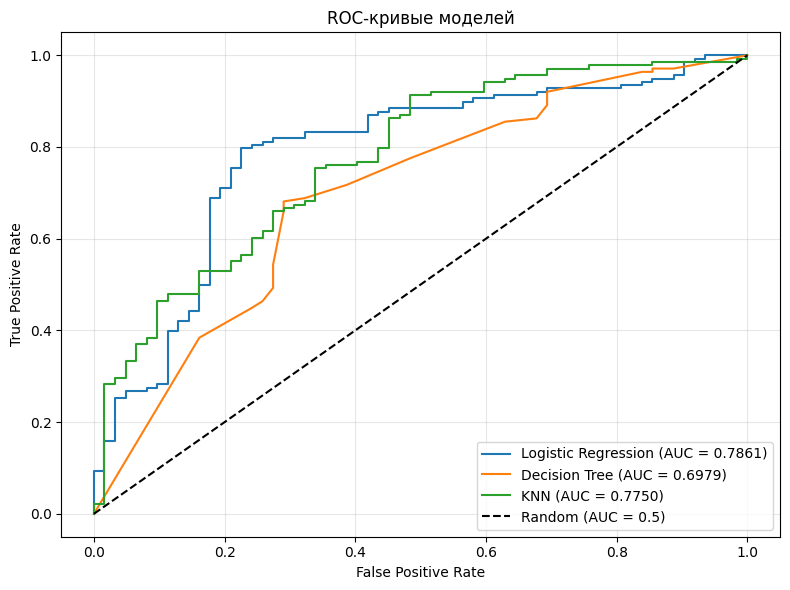

In [28]:
plt.figure(figsize=(8, 6))

for name, y_prob in [
    ('Logistic Regression', y_prob_logistic),
    ('Decision Tree',       y_prob_decision_tree),
    ('KNN',                 y_prob_knn)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Анализ важности признаков

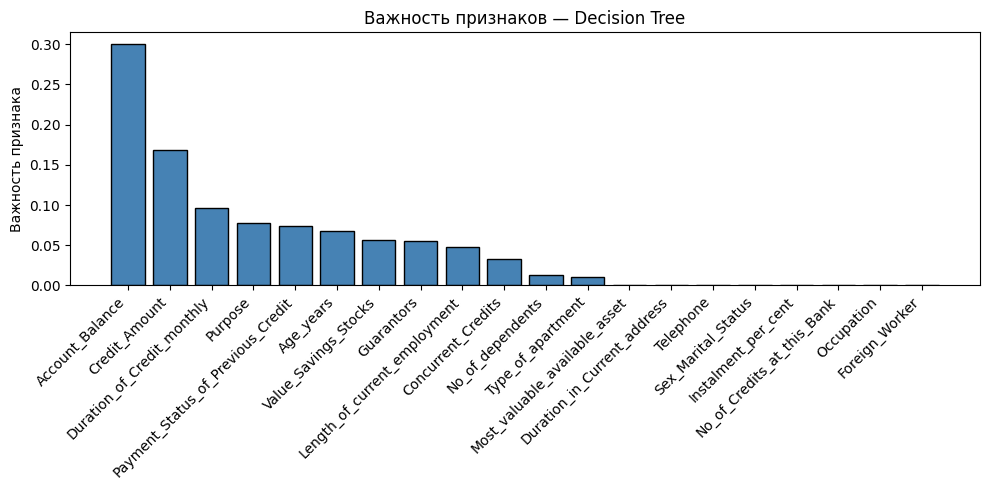

In [29]:
feature_names = data.columns[1:].tolist()
importances = decision_tree_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[indices], color='steelblue', edgecolor='k')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Важность признака')
plt.title('Важность признаков — Decision Tree')
plt.tight_layout()
plt.show()

## Дополнительные эксперименты

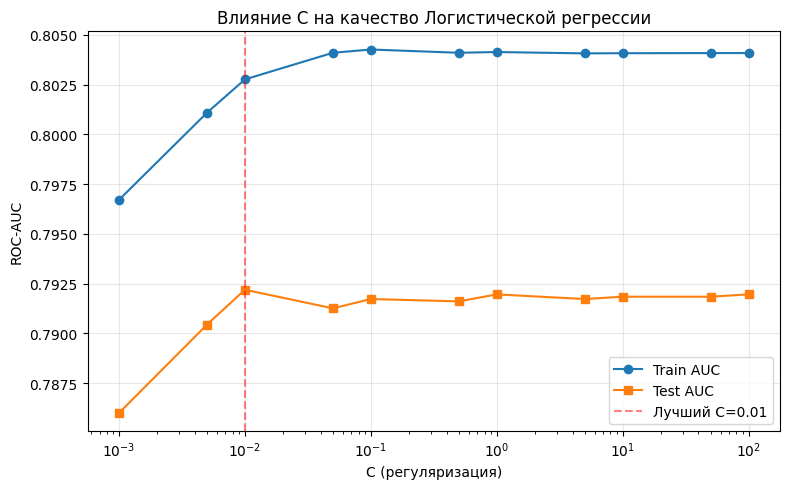

In [33]:
# Влияние гиперпараметра C на ROC-AUC (Логистическая регрессия)
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
auc_train_list = []
auc_test_list = []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=42, solver='lbfgs')
    m.fit(X_train_scaled, y_train)
    auc_train_list.append(roc_auc_score(y_train, m.predict_proba(X_train_scaled)[:, 1]))
    auc_test_list.append(roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]))

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, auc_train_list, 'o-', label='Train AUC')
plt.semilogx(C_values, auc_test_list,  's-', label='Test AUC')
plt.axvline(x=0.01, color='red', linestyle='--', alpha=0.5, label='Лучший C=0.01')
plt.xlabel('C (регуляризация)')
plt.ylabel('ROC-AUC')
plt.title('Влияние C на качество Логистической регрессии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

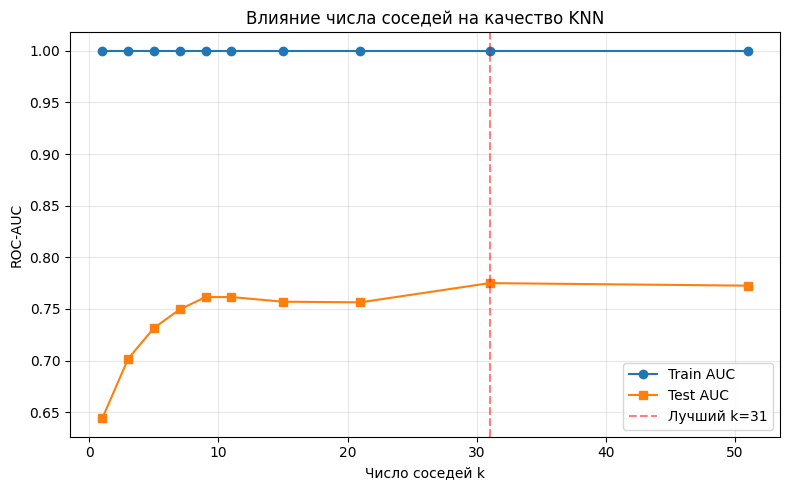

In [34]:
# Влияние числа соседей на ROC-AUC (KNN)
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
auc_k_train = []
auc_k_test = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    m.fit(X_train_scaled, y_train)
    auc_k_train.append(roc_auc_score(y_train, m.predict_proba(X_train_scaled)[:, 1]))
    auc_k_test.append(roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]))

plt.figure(figsize=(8, 5))
plt.plot(k_values, auc_k_train, 'o-', label='Train AUC')
plt.plot(k_values, auc_k_test,  's-', label='Test AUC')
plt.axvline(x=31, color='red', linestyle='--', alpha=0.5, label='Лучший k=31')
plt.xlabel('Число соседей k')
plt.ylabel('ROC-AUC')
plt.title('Влияние числа соседей на качество KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

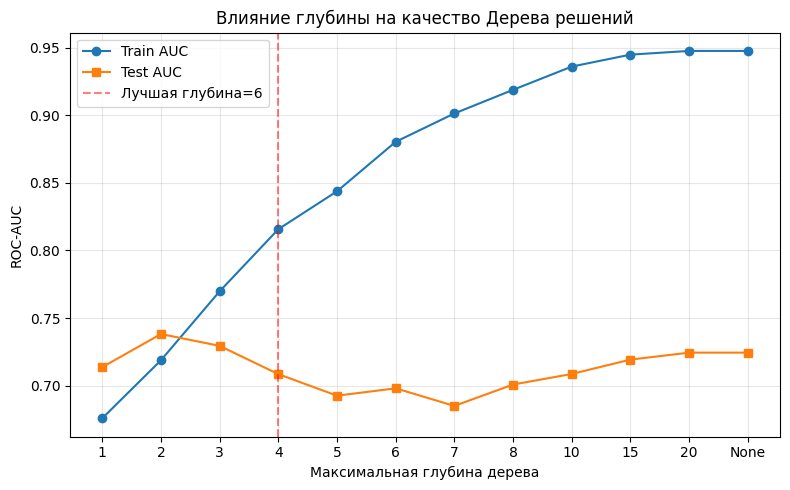

In [37]:
# Влияние глубины дерева на ROC-AUC (Дерево решений)
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
depth_labels = [str(d) if d else 'None' for d in depth_values]
auc_dt_train = []
auc_dt_test = []

for d in depth_values:
    m = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                min_samples_split=20, random_state=42)
    m.fit(X_train_scaled, y_train)
    auc_dt_train.append(roc_auc_score(y_train, m.predict_proba(X_train_scaled)[:, 1]))
    auc_dt_test.append(roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]))

plt.figure(figsize=(8, 5))
plt.plot(range(len(depth_values)), auc_dt_train, 'o-', label='Train AUC')
plt.plot(range(len(depth_values)), auc_dt_test,  's-', label='Test AUC')
plt.xticks(range(len(depth_values)), depth_labels)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Лучшая глубина=6')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('ROC-AUC')
plt.title('Влияние глубины на качество Дерева решений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Выводы

| Модель | ROC-AUC (тест) | Оценка |
|--------|---------------|--------|
| **Logistic Regression** | **~0.786** | **8 баллов** |
| KNN | ~0.775 | 4 балла |
| Decision Tree | ~0.698 | 0 баллов |

**Выводы:**

1. **Логистическая регрессия** показала лучший результат. Оптимальный C=0.01 означает сильную L2-регуляризацию — модель не переобучается.
2. **KNN** с большим числом соседей (k=31) и метрикой Manhattan стабильно работает, но уступает логистической регрессии.
3. **Дерево решений** склонно к переобучению — при глубине > 6 качество на тесте падает. Даже с подбором гиперпараметров уступает другим моделям на этом датасете.
4. Масштабирование признаков (StandardScaler) критично для LogReg и KNN.
5. GridSearchCV с 5-fold CV надёжно выбирает гиперпараметры без утечки данных.